In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.optimize import curve_fit
import camb
from camb import model, initialpower

In [22]:
diag_cov_kids5["bf_noise"] == diag_cov_me_noise

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

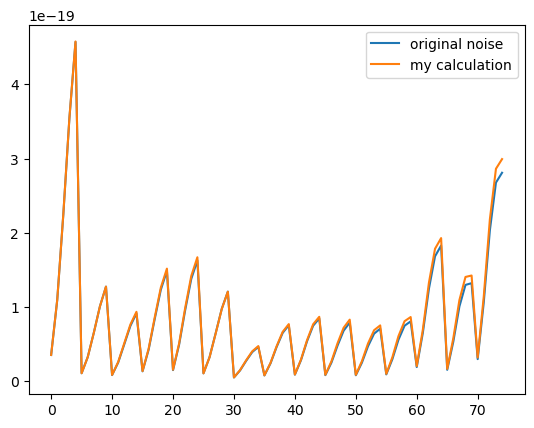

In [ ]:
cov_kids = np.loadtxt("Covariance_blindC_nMaximum_20_0.50_300.00_nBins5.ascii")
cov_kids_bf = np.loadtxt("Covariance_bestfit_3x2pt_blindC_nMaximum_20_0.50_300.00_nBins5.ascii")
cov_kids_bf_noise = np.loadtxt("Covariance_bestfit_3x2pt_blindC_nMaximum_20_0.50_300.00_nBins5_NoiseOnly.ascii")
cov_kids_noise = np.loadtxt("Covariance_blindC_nMaximum_20_0.50_300.00_nBins5_NoiseOnly.ascii")
cov_kids_bf_theoryEn = np.loadtxt("Covariance_bestfit_3x2pt_blindC_nMaximum_20_0.50_300.00_nBins5_TheoryEn.ascii")
cov_kids_cosmic = np.loadtxt("Covariance_bestfit_3x2pt_blindC_nMaximum_20_0.50_300.00_nBins5_TheoryCosmicVar.ascii")
cov_me_cosmic = np.loadtxt("Covariance_blindC_nMaximum_5_0.5_300.00_nBins5_TheoryCosmicVar.ascii")
cov_me_theoryEn = np.loadtxt("Covariance_blindC_nMaximum_5_0.5_300.00_nBins5_TheoryEn.ascii")
cov_me = np.loadtxt("Covariance_blindC_nMaximum_5_0.5_300.00_nBins5.ascii") 
cov_me_noise = np.loadtxt("Covariance_blindC_nMaximum_5_0.5_300.00_nBins5_NoiseOnly.ascii")


diag_cov_kids = np.diagonal(cov_kids)
diag_cov_kids_noise = np.diagonal(cov_kids_noise)
diag_cov_kids_bf_noise = np.diagonal(cov_kids_bf_noise)
diag_cov_me_noise = np.diagonal(cov_me_noise)
diag_cov_kids_bf = np.diagonal(cov_kids_bf)
diag_cov_kids_cosmic = np.diagonal(cov_kids_cosmic)
diag_cov_me_cosmic = np.diagonal(cov_me_cosmic)
diag_cov_me = np.diagonal(cov_me)
diag_cov_kids_bf_theoryEn = np.diagonal(cov_kids_bf_theoryEn)
diag_cov_me_theoryEn = np.diagonal(cov_me_theoryEn)

cov_kids_dict = {"no_bf" : diag_cov_kids, "bf" : diag_cov_kids_bf, "noise" : diag_cov_kids_noise, "bf_noise" : diag_cov_kids_bf_noise, "bf_theoryEn" : diag_cov_kids_bf_theoryEn, "cosmic" : diag_cov_kids_cosmic}

diag_cov_kids5 = {}
for key,data in cov_kids_dict.items() :
    diag_cov_kids5[key] = []
    for i in range(0, int(data.shape[0])) :
        diag_cov_kids5[key].extend(data[i*20:i*20+5])
    diag_cov_kids5[key] = np.array(diag_cov_kids5[key])


# diag_cov_kids5 = []
# for i in range(0,int(diag_cov_kids.shape[0])) :
#     diag_cov_kids5.extend(diag_cov_kids[i*20:i*20+5])
# diag_cov_kids5 = np.array(diag_cov_kids5)
# diag_cov_kids5_bf = []
# for i in range(0,int(diag_cov_kids_bf.shape[0])) :
#     diag_cov_kids5_bf.extend(diag_cov_kids_bf[i*20:i*20+5])
# diag_cov_kids5_bf = np.array(diag_cov_kids5_bf)

# plt.figure(figsize=(13,5))
# plt.subplot(1,2,1)
# plt.plot(diag_cov_kids5["no_bf"],label="original")
# plt.plot(diag_cov_me,label="my calculation")
# plt.legend()
# plt.subplot(1,2,2)
# plt.plot(diag_cov_kids5["bf"],label="original best fit")
# plt.plot(diag_cov_me,label="my calculation")
plt.plot(diag_cov_kids5["bf"], label = "original noise")
plt.plot(diag_cov_me, label = "my calculation")
plt.legend()

In [54]:
A=np.array([[1,2,3],[4,5,6]])
A[1,0:2]

array([4, 5])

75


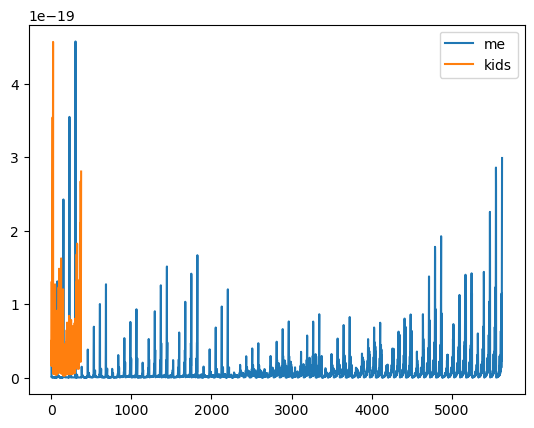

In [56]:
cov_kids_bf_1d = []
count = 0 
for i in range(0, int(cov_kids_bf.shape[0]/20)) :
    for j in range(0,5) :
        cov_kids_bf_1d.extend(cov_kids_bf[j+20*i,i*20:i*20+5])
        count = count +1
print(count)
cov_me_1d = cov_me.ravel()

plt.plot(cov_me_1d, label = "me")
plt.plot(cov_kids_bf_1d, label = "kids")
plt.legend()

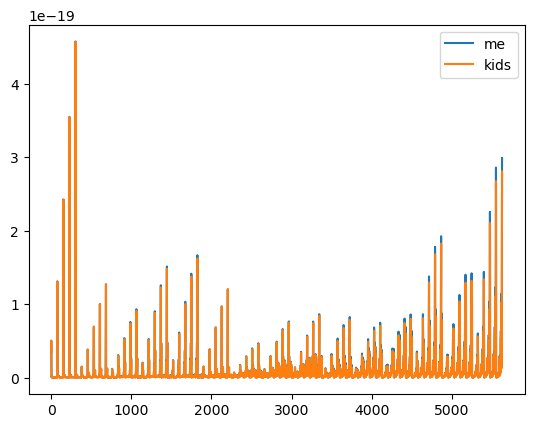

In [66]:
dum= []
for i in range(0,15) :
    row_blocks = []
    for j in range(0,15) :
        row_blocks.append(cov_kids_bf[20*i:20*i+5,20*j:20*j+5])
    
    dum.append(np.hstack(row_blocks))

cov_kids_bf_new = np.vstack(dum)


cov_kids_bf_1d = cov_kids_bf_new.ravel()
cov_me_1d = cov_me.ravel()

plt.plot(cov_me_1d, label = "me")
plt.plot(cov_kids_bf_1d, label = "kids")
plt.legend()


In [44]:
cov_me_1d.shape

(5625,)

In [4]:
cov_kids = np.loadtxt("Covariance_blindC_nMaximum_20_0.50_300.00_nBins5.ascii")
cov_kids_en = np.loadtxt("Covariance_blindC_nMaximum_20_0.50_300.00_nBins5_TheoryEn.ascii")
cov_kids_mixed = np.loadtxt("Covariance_blindC_nMaximum_20_0.50_300.00_nBins5_TheoryMixed.ascii")
cov_kids_cosmic = np.loadtxt("Covariance_blindC_nMaximum_20_0.50_300.00_nBins5_TheoryCosmicVar.ascii")

x = cov_kids_en + cov_kids_mixed + cov_kids_cosmic

(cov_kids-x)/cov_kids

array([[0.1270911 , 0.22891547, 0.36591513, ..., 1.0016952 , 1.00195089,
        0.99512987],
       [0.22891547, 0.24166169, 0.31802925, ..., 1.00494372, 1.00460026,
        0.98765486],
       [0.36591513, 0.31802925, 0.31456279, ..., 1.02279139, 1.00913115,
        0.96871429],
       ...,
       [1.0016952 , 1.00494372, 1.02279139, ..., 0.14706711, 0.18633354,
        0.30911921],
       [1.00195089, 1.00460026, 1.00913115, ..., 0.18633354, 0.16584448,
        0.20421486],
       [0.99512987, 0.98765486, 0.96871429, ..., 0.30911921, 0.20421486,
        0.18285919]])

In [5]:
diag_cov_me.shape

(75,)

In [ ]:
diag_cov_kids5_bf.shape

AttributeError: 'list' object has no attribute 'shape'

In [58]:
cov_me_1d

array([3.47949359e-20, 5.02276241e-20, 4.41944292e-20, ...,
       1.66465689e-19, 2.60613485e-19, 2.99260165e-19])

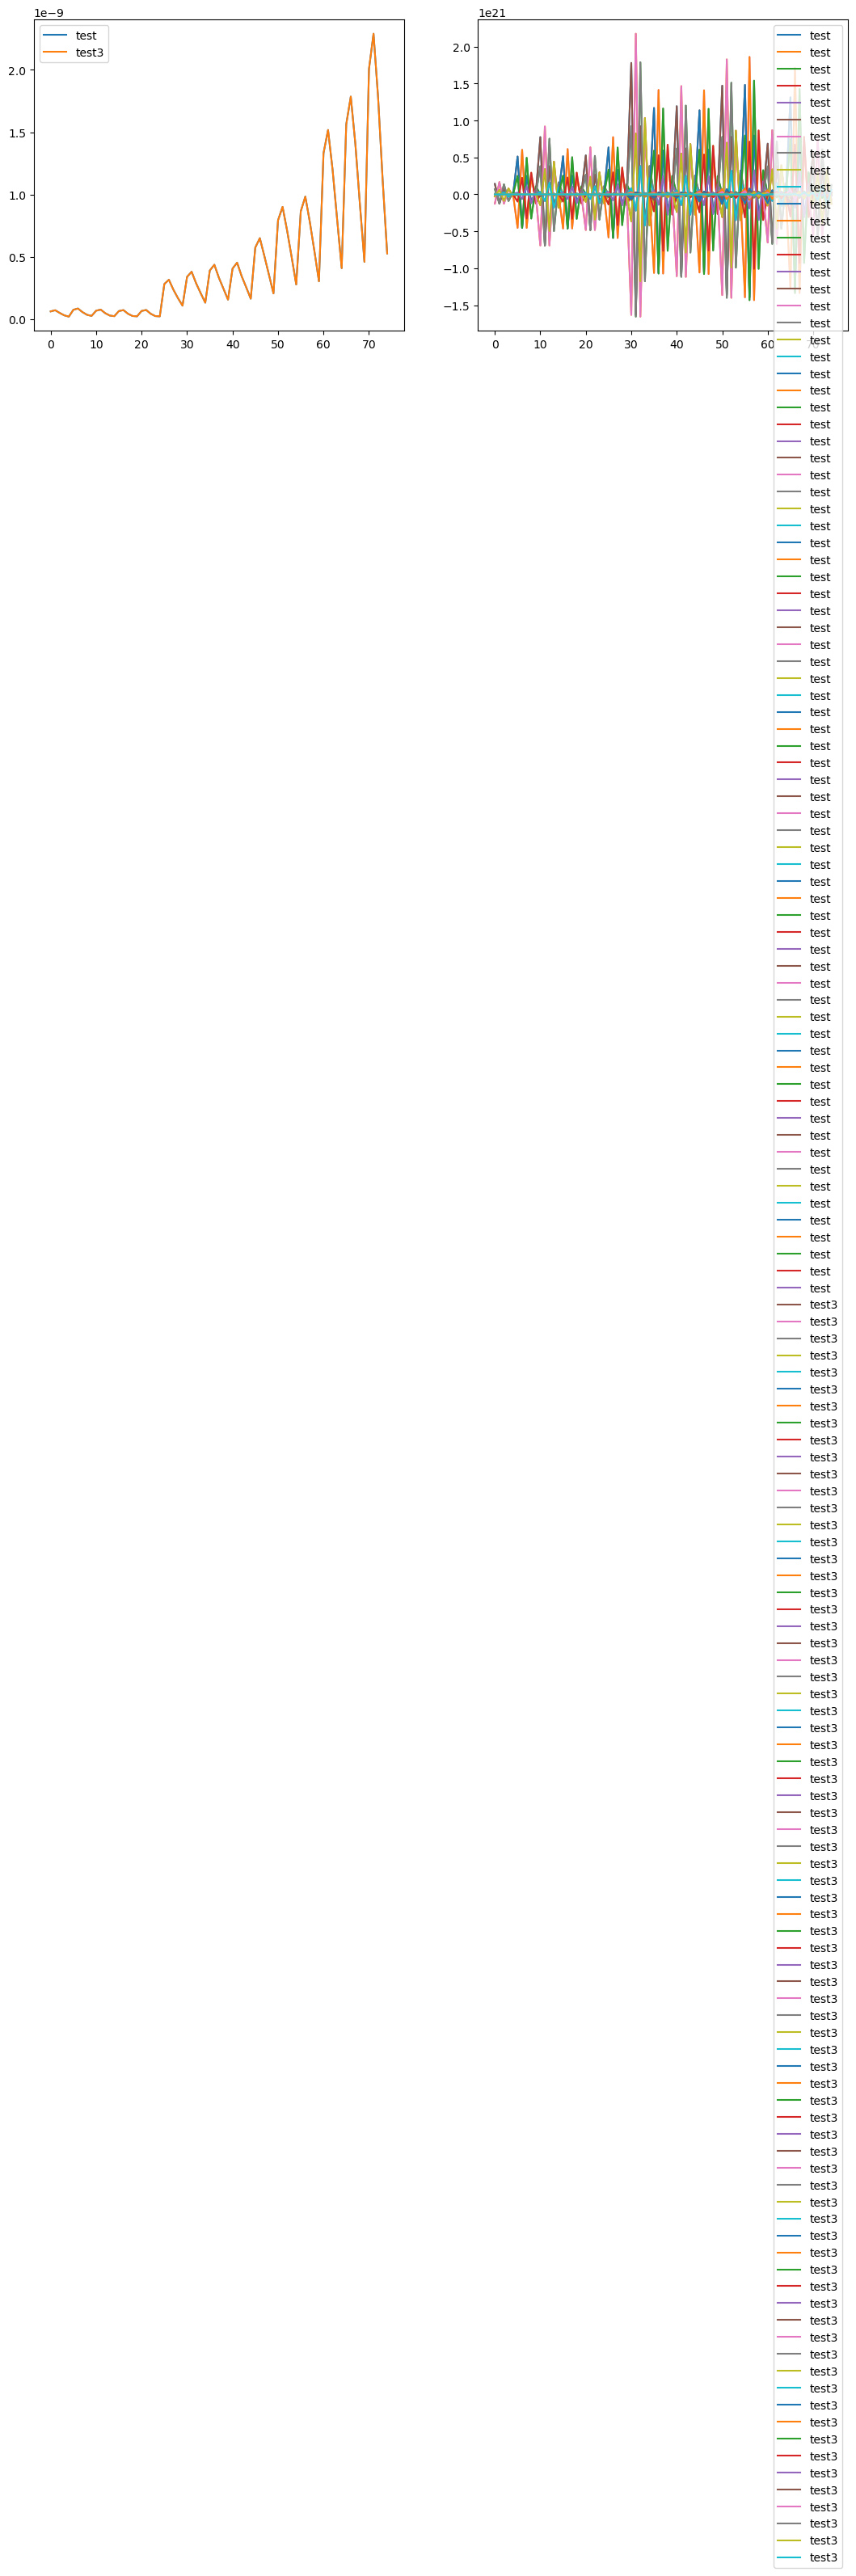

In [ ]:
cov_test = np.loadtxt("cov_theta_test.txt")
En_test = np.loadtxt("data-theory_test.txt", skiprows=1)[:,0]
cov_test3 = np.loadtxt("cov_theta_test3.txt")
En_test3 = np.loadtxt("data-theory_test3.txt", skiprows=1)[:,0]

plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.plot(En_test, label="test")
plt.plot(En_test3, label="test3")
plt.legend()

plt.subplot(1,2,2)
plt.plot(cov_test,label="test")
plt.plot(cov_test3,label="test3")
plt.legend()